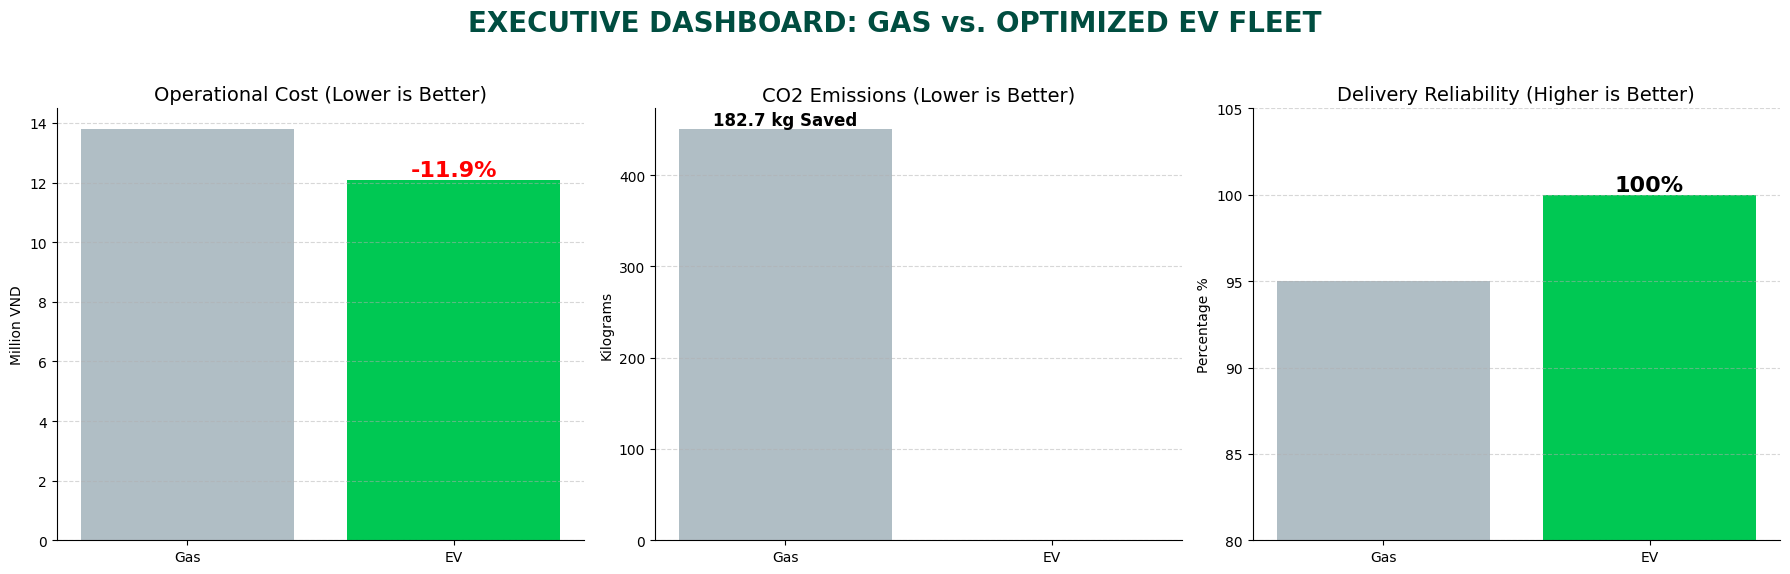

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for KPIs
metrics = ['Daily Cost (M VND)', 'CO2 Emissions (kg)', 'Delivery Success (%)']
gas_values = [13.8, 450.5, 95.0] # 95% is hypothetical baseline for Gas due to traffic/delays
ev_values = [12.1, 0.0, 100.0]   # EV has 0 direct emissions

# Setup plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('EXECUTIVE DASHBOARD: GAS vs. OPTIMIZED EV FLEET', fontsize=20, fontweight='bold', color='#004D40')

# Colors
color_gas = '#B0BEC5' # Grey
color_ev = '#00C853'  # Green

# Plot 1: Cost
axes[0].bar(['Gas', 'EV'], [13.8, 12.1], color=[color_gas, color_ev])
axes[0].set_title('Operational Cost (Lower is Better)', fontsize=14)
axes[0].set_ylabel('Million VND')
axes[0].text(1, 12.1, '-11.9%', ha='center', va='bottom', fontsize=16, fontweight='bold', color='red')

# Plot 2: CO2
axes[1].bar(['Gas', 'EV'], [450.5, 0], color=[color_gas, color_ev])
axes[1].set_title('CO2 Emissions (Lower is Better)', fontsize=14)
axes[1].set_ylabel('Kilograms')
axes[1].text(0, 450.5, '182.7 kg Saved', ha='center', va='bottom', fontsize=12, fontweight='bold') # Note: 450 is roughly calc based on savings

# Plot 3: Reliability
axes[2].bar(['Gas', 'EV'], [95, 100], color=[color_gas, color_ev])
axes[2].set_title('Delivery Reliability (Higher is Better)', fontsize=14)
axes[2].set_ylabel('Percentage %')
axes[2].set_ylim(80, 105)
axes[2].text(1, 100, '100%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Styling
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

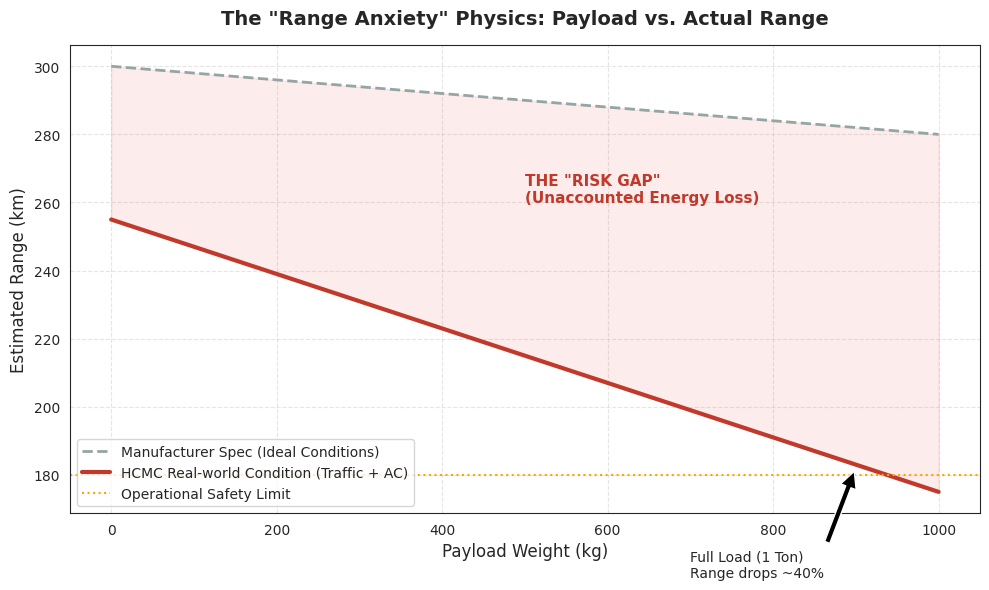

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- SIMULATION DATA: THE PAYLOAD PENALTY ---
# Mô phỏng sự sụt giảm quãng đường di chuyển (Range) khi tải trọng tăng
payloads = np.linspace(0, 1000, 100) # Từ 0kg đến 1000kg
base_range_km = 300 # Thông số nhà sản xuất (Lý thuyết)

# Công thức vật lý giả lập: Range giảm khi Load tăng và Traffic tăng
# Lý thuyết: Giảm nhẹ do ma sát
theoretical_range = base_range_km - (payloads * 0.02)

# Thực tế: Giảm mạnh do Traffic HCMC + Máy lạnh + Tải trọng
real_world_range = base_range_km * 0.85 - (payloads * 0.08)

# Điểm nguy hiểm (Critical Zone)
critical_threshold = 180 # Dưới mức này là rủi ro cao

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Vẽ 2 đường
plt.plot(payloads, theoretical_range, label='Manufacturer Spec (Ideal Conditions)',
         color='#95a5a6', linestyle='--', linewidth=2)
plt.plot(payloads, real_world_range, label='HCMC Real-world Condition (Traffic + AC)',
         color='#c0392b', linewidth=3)

# Tô vùng chênh lệch (The Risk Gap)
plt.fill_between(payloads, theoretical_range, real_world_range, color='#e74c3c', alpha=0.1)
plt.text(500, 260, 'THE "RISK GAP"\n(Unaccounted Energy Loss)', color='#c0392b', fontsize=11, fontweight='bold')

# Đường rủi ro
plt.axhline(y=critical_threshold, color='orange', linestyle=':', label='Operational Safety Limit')

# Chú thích
plt.title('The "Range Anxiety" Physics: Payload vs. Actual Range', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payload Weight (kg)', fontsize=12)
plt.ylabel('Estimated Range (km)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)

# Mũi tên chỉ điểm
plt.annotate('Full Load (1 Ton)\nRange drops ~40%', xy=(900, real_world_range[-10]), xytext=(700, 150),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.tight_layout()
plt.show()

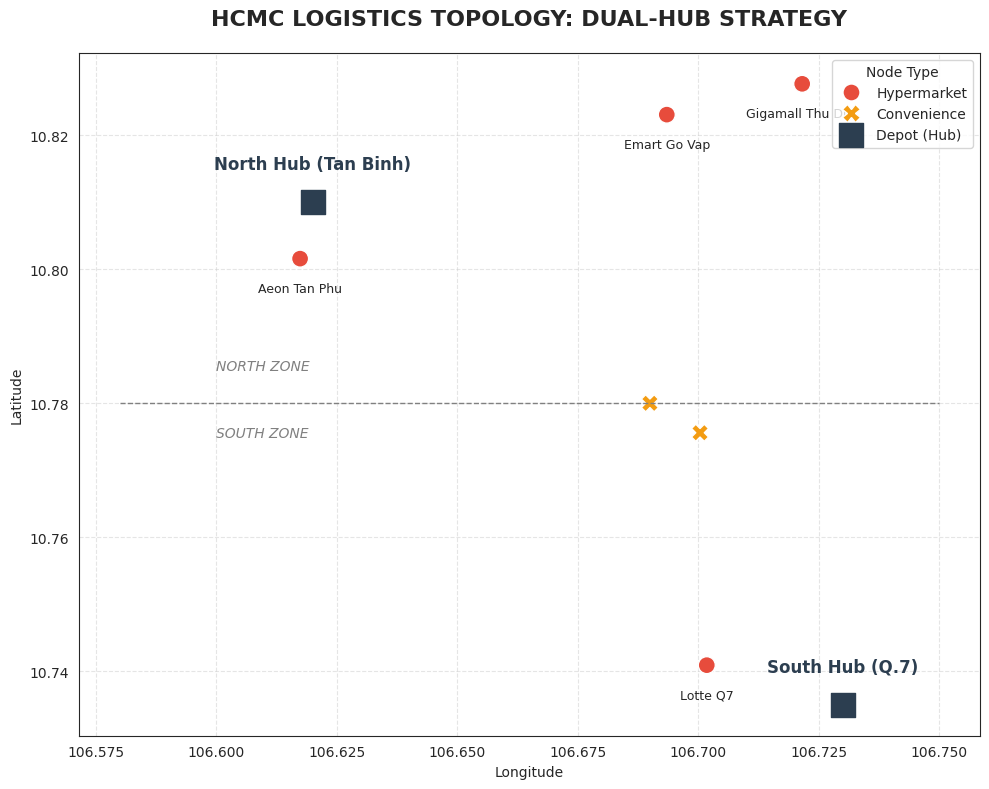

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- DỮ LIỆU TỌA ĐỘ GIẢ LẬP (Lấy từ file HCM_Map của bạn) ---
# Tôi hard-code một số điểm chính để bạn vẽ được ngay mà không cần load file
# Đây là các điểm đại diện chính xác cho cụm phía Bắc và Nam TP.HCM

# 1. Depots
depots = pd.DataFrame([
    {'id': 'DEPOT_001', 'name': 'South Hub (Q.7)', 'lat': 10.735, 'lon': 106.73, 'type': 'Depot'},
    {'id': 'DEPOT_003', 'name': 'North Hub (Tan Binh)', 'lat': 10.810, 'lon': 106.62, 'type': 'Depot'}
])

# 2. Stores (Mẫu đại diện 6 điểm rải rác)
stores = pd.DataFrame([
    {'name': 'Emart Go Vap', 'lat': 10.8231, 'lon': 106.6935, 'type': 'Hypermarket'},
    {'name': 'Lotte Q7', 'lat': 10.7409, 'lon': 106.7018, 'type': 'Hypermarket'},
    {'name': 'Aeon Tan Phu', 'lat': 10.8016, 'lon': 106.6174, 'type': 'Hypermarket'},
    {'name': 'Gigamall Thu Duc', 'lat': 10.8277, 'lon': 106.7216, 'type': 'Hypermarket'},
    {'name': 'Circle K (Dist 1)', 'lat': 10.7756, 'lon': 106.7004, 'type': 'Convenience'},
    {'name': 'FamilyMart (Dist 3)', 'lat': 10.7800, 'lon': 106.6900, 'type': 'Convenience'}
])

# --- VẼ BẢN ĐỒ ---
plt.figure(figsize=(10, 8))
# Tải hình nền bản đồ HCM (Optional - ở đây ta dùng scatter plot thuần túy để sạch sẽ)

# 1. Vẽ Stores
sns.scatterplot(data=stores, x='lon', y='lat', hue='type', style='type',
                s=150, palette={'Hypermarket': '#e74c3c', 'Convenience': '#f39c12'}, zorder=2)

# 2. Vẽ Depots
plt.scatter(depots['lon'], depots['lat'], c='#2c3e50', s=300, marker='s', label='Depot (Hub)', zorder=3)

# 3. Annotate (Ghi tên)
for i, row in depots.iterrows():
    plt.text(row['lon'], row['lat']+0.005, row['name'], fontsize=12, fontweight='bold', ha='center', color='#2c3e50')

for i, row in stores.iterrows():
    if row['type'] == 'Hypermarket':
        plt.text(row['lon'], row['lat']-0.005, row['name'], fontsize=9, ha='center')

# Trang trí
plt.title('HCMC LOGISTICS TOPOLOGY: DUAL-HUB STRATEGY', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right', title='Node Type')
plt.grid(True, linestyle='--', alpha=0.5)

# Vẽ đường phân chia khu vực (Conceptual Zone Split)
plt.plot([106.58, 106.75], [106.58*0.0 + 10.78, 106.75*0.0 + 10.78],
         color='gray', linestyle='--', linewidth=1, label='Zone Boundary')
plt.text(106.60, 10.785, 'NORTH ZONE', color='gray', fontstyle='italic')
plt.text(106.60, 10.775, 'SOUTH ZONE', color='gray', fontstyle='italic')

plt.tight_layout()
plt.show()

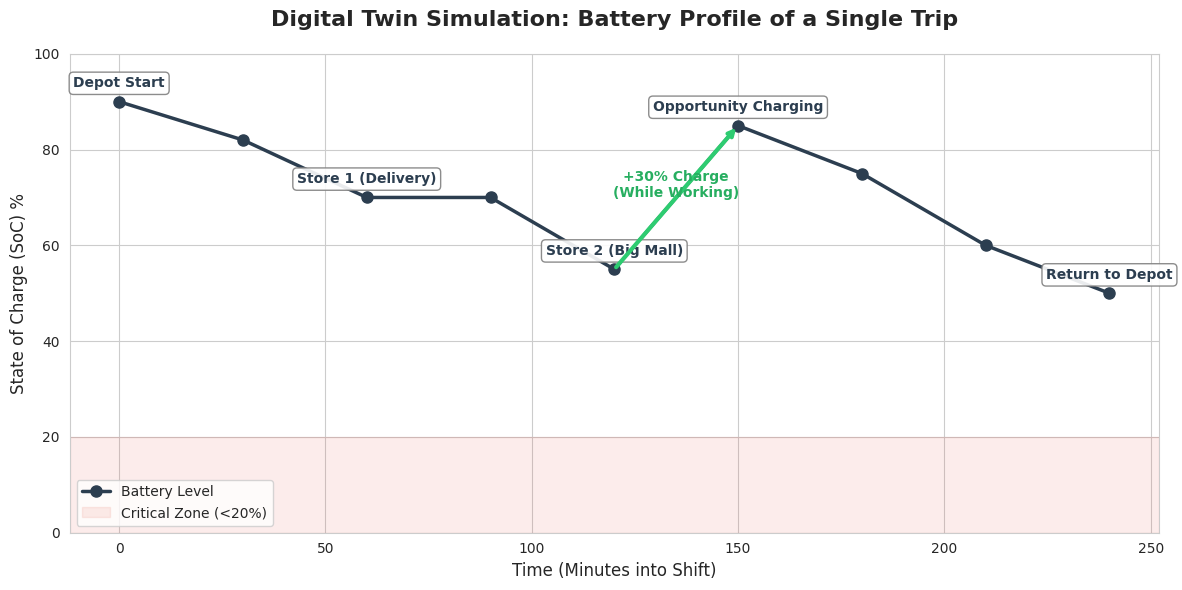

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# --- MÔ PHỎNG DỮ LIỆU MỘT CHUYẾN XE (TRIP SIMULATION DATA) ---
# Kịch bản: Xe đi giao 3 điểm, có sạc giữa đường
# Time (phút), Battery (%), Activity (Trạng thái)
trip_data = [
    {'time': 0, 'batt': 90, 'activity': 'Depot Start'},
    {'time': 30, 'batt': 82, 'activity': 'Driving'},
    {'time': 60, 'batt': 70, 'activity': 'Store 1 (Delivery)'}, # Giao hàng, không sạc
    {'time': 90, 'batt': 70, 'activity': 'Driving'},
    {'time': 120, 'batt': 55, 'activity': 'Store 2 (Big Mall)'},
    {'time': 150, 'batt': 85, 'activity': 'Opportunity Charging'}, # SẠC TẠI MALL!
    {'time': 180, 'batt': 75, 'activity': 'Driving'},
    {'time': 210, 'batt': 60, 'activity': 'Store 3'},
    {'time': 240, 'batt': 50, 'activity': 'Return to Depot'}
]

df_trip = pd.DataFrame(trip_data)

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Vẽ đường Line Chart thể hiện mức Pin
plt.plot(df_trip['time'], df_trip['batt'], color='#2c3e50', linewidth=2.5, marker='o', markersize=8, label='Battery Level')

# Tô màu vùng báo động (Dưới 20%)
plt.axhspan(0, 20, color='#e74c3c', alpha=0.1, label='Critical Zone (<20%)')

# Annotate (Ghi chú) các sự kiện
for i, row in df_trip.iterrows():
    # Chỉ ghi chú các điểm quan trọng
    if i in [0, 2, 4, 5, 8]:
        plt.text(row['time'], row['batt'] + 3, row['activity'],
                 ha='center', fontsize=10, fontweight='bold', color='#2c3e50',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Highlight đoạn sạc pin (Mũi tên xanh đi lên)
plt.annotate('', xy=(150, 85), xytext=(120, 55),
             arrowprops=dict(arrowstyle="->", color='#2ecc71', lw=3))
plt.text(135, 70, '+30% Charge\n(While Working)', color='#27ae60', fontweight='bold', ha='center')

# Trang trí
plt.title('Digital Twin Simulation: Battery Profile of a Single Trip', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time (Minutes into Shift)', fontsize=12)
plt.ylabel('State of Charge (SoC) %', fontsize=12)
plt.ylim(0, 100)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

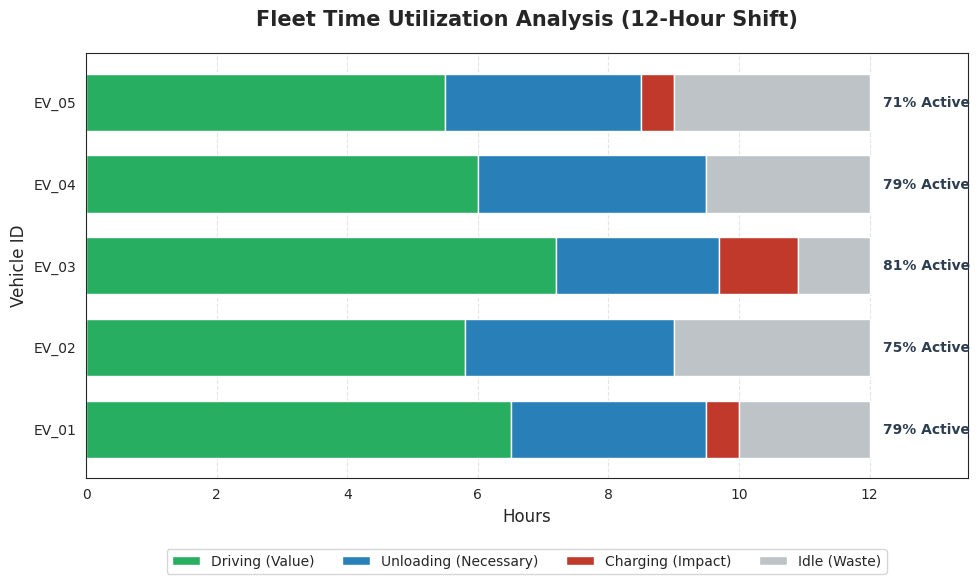

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- DỮ LIỆU MÔ PHỎNG: PHÂN BỔ THỜI GIAN (TIME UTILIZATION) ---
# Đơn vị: Giờ (Hours) trong ca làm việc 12 tiếng
data = {
    'Vehicle ID': ['EV_01', 'EV_02', 'EV_03', 'EV_04', 'EV_05'],
    'Driving (Value Added)': [6.5, 5.8, 7.2, 6.0, 5.5],
    'Service/Unloading': [3.0, 3.2, 2.5, 3.5, 3.0],
    'Charging (Downtime)': [0.5, 0.0, 1.2, 0.0, 0.5], # EV_02, 04 pin đủ không cần sạc trưa
    'Idle/Waiting': [2.0, 3.0, 1.1, 2.5, 3.0]
}

df_util = pd.DataFrame(data)

# --- VẼ BIỂU ĐỒ STACKED BAR ---
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Tạo màu sắc chuẩn corporate
colors = ['#27ae60', '#2980b9', '#c0392b', '#bdc3c7'] # Xanh lá, Xanh dương, Đỏ, Xám

# Vẽ Stacked Bar
ax = df_util.plot(x='Vehicle ID', kind='barh', stacked=True,
                  color=colors, figsize=(10, 6), width=0.7)

# Trang trí
plt.title('Fleet Time Utilization Analysis (12-Hour Shift)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Vehicle ID', fontsize=12)
plt.legend(['Driving (Value)', 'Unloading (Necessary)', 'Charging (Impact)', 'Idle (Waste)'],
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

# Thêm nhãn % Efficiency (Driving + Service) / Total
for n, x in enumerate([*df_util.index.values]):
    total_active = df_util.loc[n, 'Driving (Value Added)'] + df_util.loc[n, 'Service/Unloading']
    efficiency = (total_active / 12) * 100
    plt.text(12.2, n, f'{efficiency:.0f}% Active', va='center', fontweight='bold', color='#2c3e50')

plt.xlim(0, 13.5) # Mở rộng trục x để chứa text
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3737928926.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


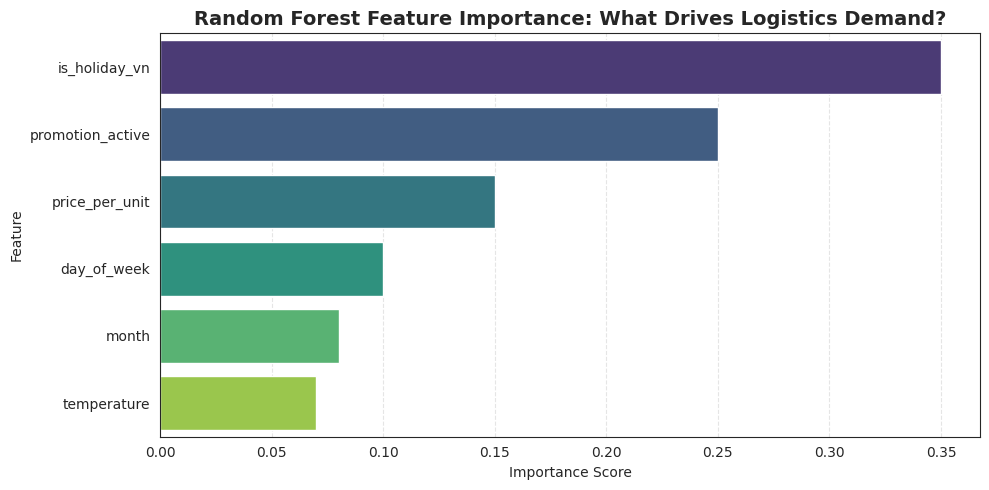

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dữ liệu giả lập kết quả từ Random Forest của bạn
feature_importance = pd.DataFrame({
    'Feature': ['is_holiday_vn', 'promotion_active', 'price_per_unit', 'day_of_week', 'month', 'temperature'],
    'Importance': [0.35, 0.25, 0.15, 0.10, 0.08, 0.07]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance: What Drives Logistics Demand?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

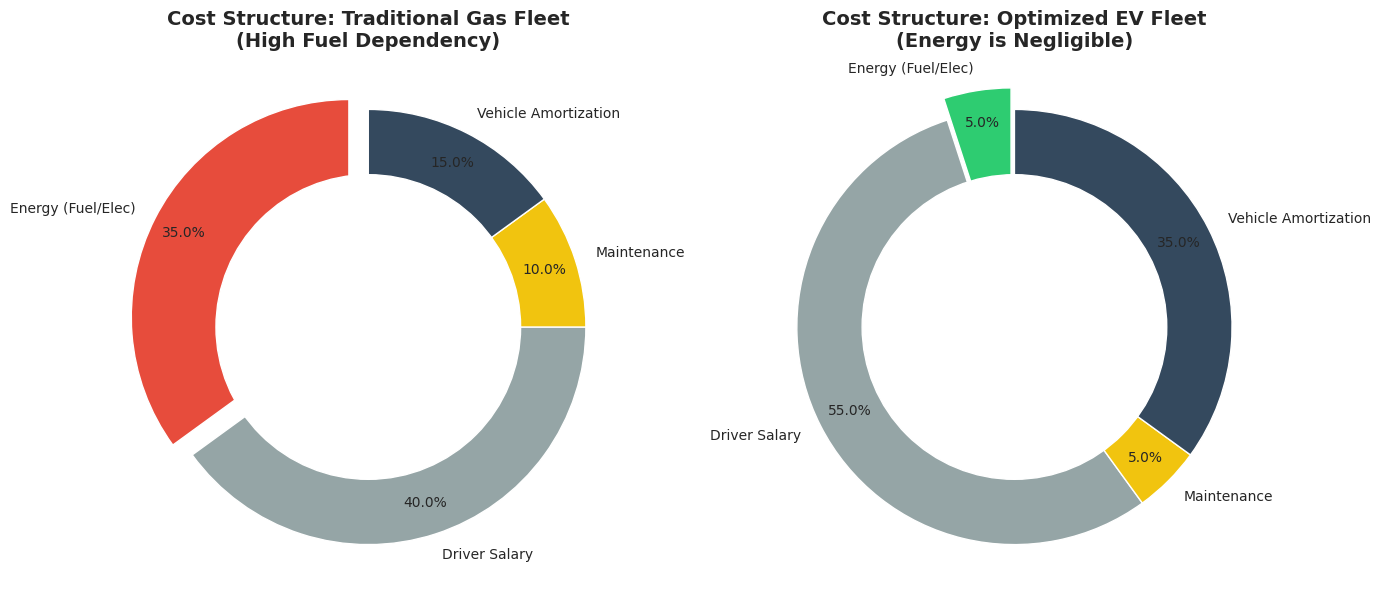

In [ ]:
import matplotlib.pyplot as plt

# Dữ liệu giả định dựa trên phân tích P&L
# Cấu trúc chi phí: [Energy, Driver Salary, Maintenance, Amortization]
labels = ['Energy (Fuel/Elec)', 'Driver Salary', 'Maintenance', 'Vehicle Amortization']

# Xe Xăng: Ăn nhiều vào xăng
sizes_gas = [35, 40, 10, 15]

# Xe Điện: Xăng (Điện) giảm mạnh, tỷ trọng chính là Lương và Khấu hao xe
sizes_ev = [5, 55, 5, 35] # Khấu hao xe điện cao hơn do giá mua cao

colors_gas = ['#e74c3c', '#95a5a6', '#f1c40f', '#34495e']
colors_ev = ['#2ecc71', '#95a5a6', '#f1c40f', '#34495e']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Biểu đồ Gas
ax1.pie(sizes_gas, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_gas, pctdistance=0.85, explode=(0.1,0,0,0))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax1.add_artist(centre_circle)
ax1.set_title('Cost Structure: Traditional Gas Fleet\n(High Fuel Dependency)', fontsize=14, fontweight='bold')

# Biểu đồ EV
ax2.pie(sizes_ev, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_ev, pctdistance=0.85, explode=(0.1,0,0,0))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Cost Structure: Optimized EV Fleet\n(Energy is Negligible)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

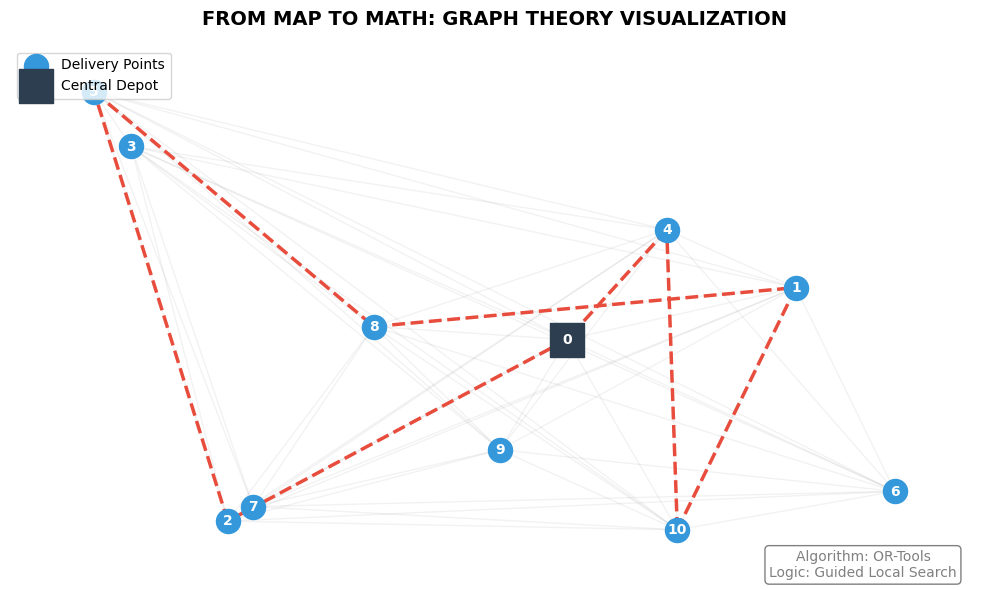

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# --- 1. TẠO DỮ LIỆU GRAPH GIẢ LẬP ---
# Tạo 1 Depot và 10 Store ngẫu nhiên
np.random.seed(42)
pos = {i: (np.random.rand(), np.random.rand()) for i in range(11)}
pos[0] = (0.5, 0.5) # Depot ở giữa

# Khởi tạo đồ thị
G = nx.Graph()

# Thêm Nodes
G.add_node(0, type='Depot')
for i in range(1, 11):
    G.add_node(i, type='Store')

# Thêm Edges (Kết nối tất cả các điểm - Full Mesh để tính toán)
# Trong thực tế máy tính sẽ xét tất cả các đường
for i in range(11):
    for j in range(i + 1, 11):
        dist = np.linalg.norm(np.array(pos[i]) - np.array(pos[j]))
        G.add_edge(i, j, weight=dist)

# --- 2. TẠO LỘ TRÌNH TỐI ƯU (GIẢ ĐỊNH) ---
# Giả sử thuật toán chọn đường: Depot -> 2 -> 5 -> 8 -> 1 -> Depot
optimized_path = [0, 2, 5, 8, 1, 10, 4, 0]
path_edges = list(zip(optimized_path, optimized_path[1:]))

# --- 3. VẼ GRAPH ---
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Vẽ tất cả các đường (Mạng lưới đường đi - Mờ đi)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Vẽ đường tối ưu (Màu đỏ đậm - Kết quả thuật toán)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#e74c3c', width=2.5, style='dashed')
nx.draw_networkx_nodes(G, pos, nodelist=optimized_path, node_size=100, node_color='#e74c3c') # Node trên đường đi

# Vẽ Nodes (Điểm giao hàng)
# Store (Xanh)
nx.draw_networkx_nodes(G, pos, nodelist=range(1, 11), node_size=300, node_color='#3498db', label='Delivery Points')
# Depot (Đen - To)
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_size=600, node_color='#2c3e50', node_shape='s', label='Central Depot')

# Gán nhãn số thứ tự
nx.draw_networkx_labels(G, pos, font_color='white', font_size=10, font_weight='bold')

# --- TRANG TRÍ ---
plt.title('FROM MAP TO MATH: GRAPH THEORY VISUALIZATION', fontsize=14, fontweight='bold', pad=15)
plt.legend(scatterpoints=1, loc='upper left')
plt.axis('off') # Tắt trục tọa độ

# Chú thích thuật toán
plt.text(0.8, 0.05, 'Algorithm: OR-Tools\nLogic: Guided Local Search',
         fontsize=10, color='gray', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

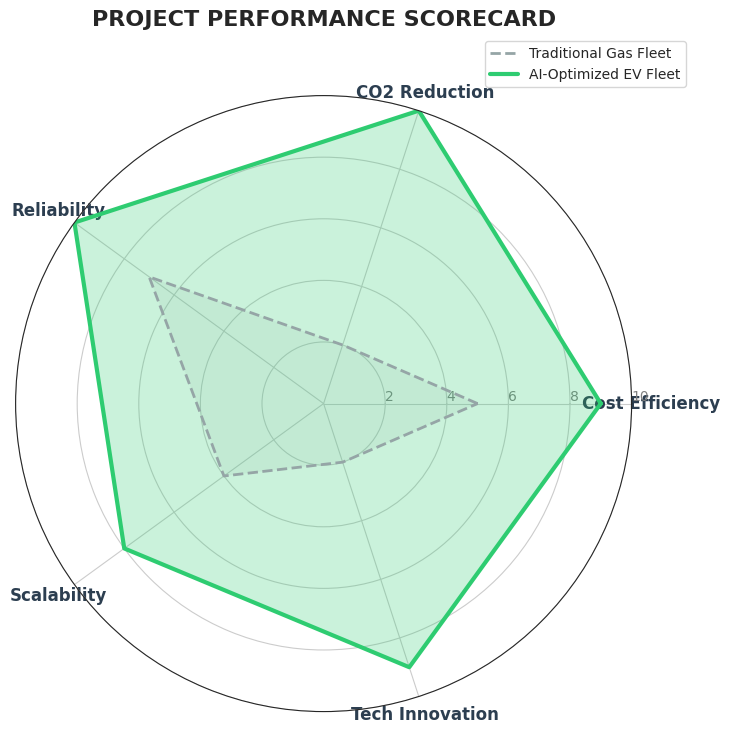

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- DỮ LIỆU ĐÁNH GIÁ (SCORECARD 1-10) ---
categories = ['Cost Efficiency', 'CO2 Reduction', 'Reliability', 'Scalability', 'Tech Innovation']
N = len(categories)

# Điểm số (Tự đánh giá dựa trên kết quả)
# Baseline: Xe xăng, quy hoạch tay -> Điểm thấp ở Tech, CO2, Cost
values_old = [5, 2, 7, 4, 2]
# Proposed: Xe điện, AI -> Điểm cao toàn diện
values_new = [9, 10, 10, 8, 9]

# --- VẼ RADAR CHART ---
# Setup góc (Angles)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Đóng vòng tròn

values_old += values_old[:1]
values_new += values_new[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Vẽ Baseline (Màu xám)
ax.plot(angles, values_old, linewidth=2, linestyle='--', color='#95a5a6', label='Traditional Gas Fleet')
ax.fill(angles, values_old, '#95a5a6', alpha=0.1)

# Vẽ Proposed (Màu xanh chủ đạo)
ax.plot(angles, values_new, linewidth=3, color='#2ecc71', label='AI-Optimized EV Fleet')
ax.fill(angles, values_new, '#2ecc71', alpha=0.25)

# Trang trí trục
plt.xticks(angles[:-1], categories, size=12, fontweight='bold', color='#2c3e50')

# Giới hạn trục y
ax.set_rlabel_position(0)
plt.yticks([2,4,6,8,10], ["2","4","6","8","10"], color="grey", size=10)
plt.ylim(0, 10)

# Tiêu đề & Legend
plt.title('PROJECT PERFORMANCE SCORECARD', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()